#Imports

In [ ]:
import sys
assert sys.version_info >= (3, 5)
# Python ≥3.5 is required


In [ ]:
# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

In [ ]:
# Common imports
import numpy as np
import os
import tarfile
import urllib
import pandas as pd
import urllib.request


In [ ]:
# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, learning_curve
from scipy.stats import randint

#Loading Dataset

In [25]:
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/MeGaaaaMind/mldm/refs/heads/main/data/"
WILDFIRE_PATH = os.path.join("datasets", "wildfire")
WILDFIRE_URL = DOWNLOAD_ROOT + "FW_Veg_Rem_Combined.csv"

def fetch_wildfire_data(wildfire_url=WILDFIRE_URL, wildfire_path=WILDFIRE_PATH):
    os.makedirs(wildfire_path, exist_ok=True)
    csv_path = os.path.join(wildfire_path, "FW_Veg_Rem_Combined.csv")
    urllib.request.urlretrieve(wildfire_url, csv_path)  # download file
    return csv_path

csv_path = fetch_wildfire_data()
wildfire = pd.read_csv(csv_path)
print(wildfire.head())

   Unnamed: 0.1  Unnamed: 0 fire_name  fire_size fire_size_class  \
0             0           0       NaN       10.0               C   
1             1           1       NaN        3.0               B   
2             2           2       NaN       60.0               C   
3             3           3    WNA  1        1.0               B   
4             4           4       NaN        2.0               B   

    stat_cause_descr   latitude   longitude state disc_clean_date  ...  \
0  Missing/Undefined  18.105072  -66.753044    PR       2/11/2007  ...   
1              Arson  35.038330  -87.610000    TN      12/11/2006  ...   
2              Arson  34.947800  -88.722500    MS       2/29/2004  ...   
3     Debris Burning  39.641400 -119.308300    NV        6/6/2005  ...   
4      Miscellaneous  30.700600  -90.591400    LA       9/22/1999  ...   

  Wind_cont Hum_pre_30 Hum_pre_15  Hum_pre_7   Hum_cont Prec_pre_30  \
0  3.250413  78.216590  76.793750  76.381579  78.724370         0.0   
1  2

In [ ]:
fetch_wildfire_data()

'datasets/wildfire/FW_Veg_Rem_Combined.csv'

#Data Analysis



In [ ]:
wildfire.head() # Display the top five rows of the DataFrame

,Unnamed: 0.1,Unnamed: 0,fire_name,fire_size,fire_size_class,stat_cause_descr,latitude,longitude,state,disc_clean_date,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
0,0,0,NaN,10.0,C,Missing/Undefined,18.105072,-66.753044,PR,2/11/2007,...,3.250413,78.216590,76.793750,76.381579,78.724370,0.0,0.0,0.0,0.0,0.017923
1,1,1,NaN,3.0,B,Arson,35.038330,-87.610000,TN,12/11/2006,...,2.122320,70.840000,65.858911,55.505882,81.682678,59.8,8.4,0.0,86.8,0.184355
2,2,2,NaN,60.0,C,Arson,34.947800,-88.722500,MS,2/29/2004,...,3.369050,75.531629,75.868613,76.812834,65.063800,168.8,42.2,18.1,124.5,0.194544
3,3,3,WNA 1,1.0,B,Debris Burning,39.641400,-119.308300,NV,6/6/2005,...,0.000000,44.778429,37.140811,35.353846,0.000000,10.4,7.2,0.0,0.0,0.487447
4,4,4,NaN,2.0,B,Miscellaneous,30.700600,-90.591400,LA,9/22/1999,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.214633


In [ ]:
#This method prints information about a DataFrame including the dtype and columns, non-null values and memory usage.
wildfire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55367 entries, 0 to 55366
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      55367 non-null  int64  
 1   Unnamed: 0        55367 non-null  int64  
 2   fire_name         25913 non-null  object 
 3   fire_size         55367 non-null  float64
 4   fire_size_class   55367 non-null  object 
 5   stat_cause_descr  55367 non-null  object 
 6   latitude          55367 non-null  float64
 7   longitude         55367 non-null  float64
 8   state             55367 non-null  object 
 9   disc_clean_date   55367 non-null  object 
 10  cont_clean_date   27477 non-null  object 
 11  discovery_month   55367 non-null  object 
 12  disc_date_final   28708 non-null  object 
 13  cont_date_final   25632 non-null  object 
 14  putout_time       27477 non-null  object 
 15  disc_date_pre     55367 non-null  object 
 16  disc_pre_year     55367 non-null  int64 

In [ ]:
#This method shows a statistical summary of the numerical attributes
wildfire.describe()

,fire_size,latitude,longitude,disc_pre_year,dstation_m,wstation_wban,wstation_byear,wstation_eyear,Vegetation,fire_mag,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
count,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,...,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000,55367.000000
mean,2104.645161,36.172866,-94.757971,2003.765474,40256.474678,61029.607311,1979.341900,2015.480990,11.066068,9.414366,...,1.132284,40.781796,38.453935,37.001865,25.056738,26.277046,11.654253,4.689920,15.590440,0.236799
std,14777.005364,6.724348,15.878194,6.584889,25272.081410,40830.393541,23.372803,6.767851,5.595719,26.820363,...,2.030611,31.086856,31.042541,30.827885,31.187638,112.050198,56.920510,31.205327,59.757113,0.144865
min,0.510000,17.956533,-165.936000,1991.000000,6.166452,100.000000,1931.000000,1993.000000,0.000000,0.100000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,1.200000,32.265960,-102.541513,1999.000000,21373.361515,13927.000000,1973.000000,2010.000000,9.000000,0.100000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.137800
50%,4.000000,34.600000,-91.212359,2005.000000,35621.334820,73803.000000,1978.000000,2020.000000,12.000000,0.100000,...,0.000000,55.657480,51.753846,48.230769,0.000000,0.000000,0.000000,0.000000,0.000000,0.202114
75%,20.000000,38.975235,-82.847500,2009.000000,53985.904315,99999.000000,2004.000000,2020.000000,15.000000,1.000000,...,2.848603,67.384352,65.911469,64.645296,60.193606,18.900000,3.600000,0.000000,0.000000,0.284782
max,606945.000000,69.849500,-65.285833,2015.000000,224153.661800,99999.000000,2014.000000,2020.000000,16.000000,100.000000,...,24.200000,96.000000,94.000000,96.000000,94.000000,13560.800000,2527.000000,1638.000000,2126.000000,1.000000


In [ ]:
print(wildfire['fire_size'].describe())

count     55367.000000
mean       2104.645161
std       14777.005364
min           0.510000
25%           1.200000
50%           4.000000
75%          20.000000
max      606945.000000
Name: fire_size, dtype: float64


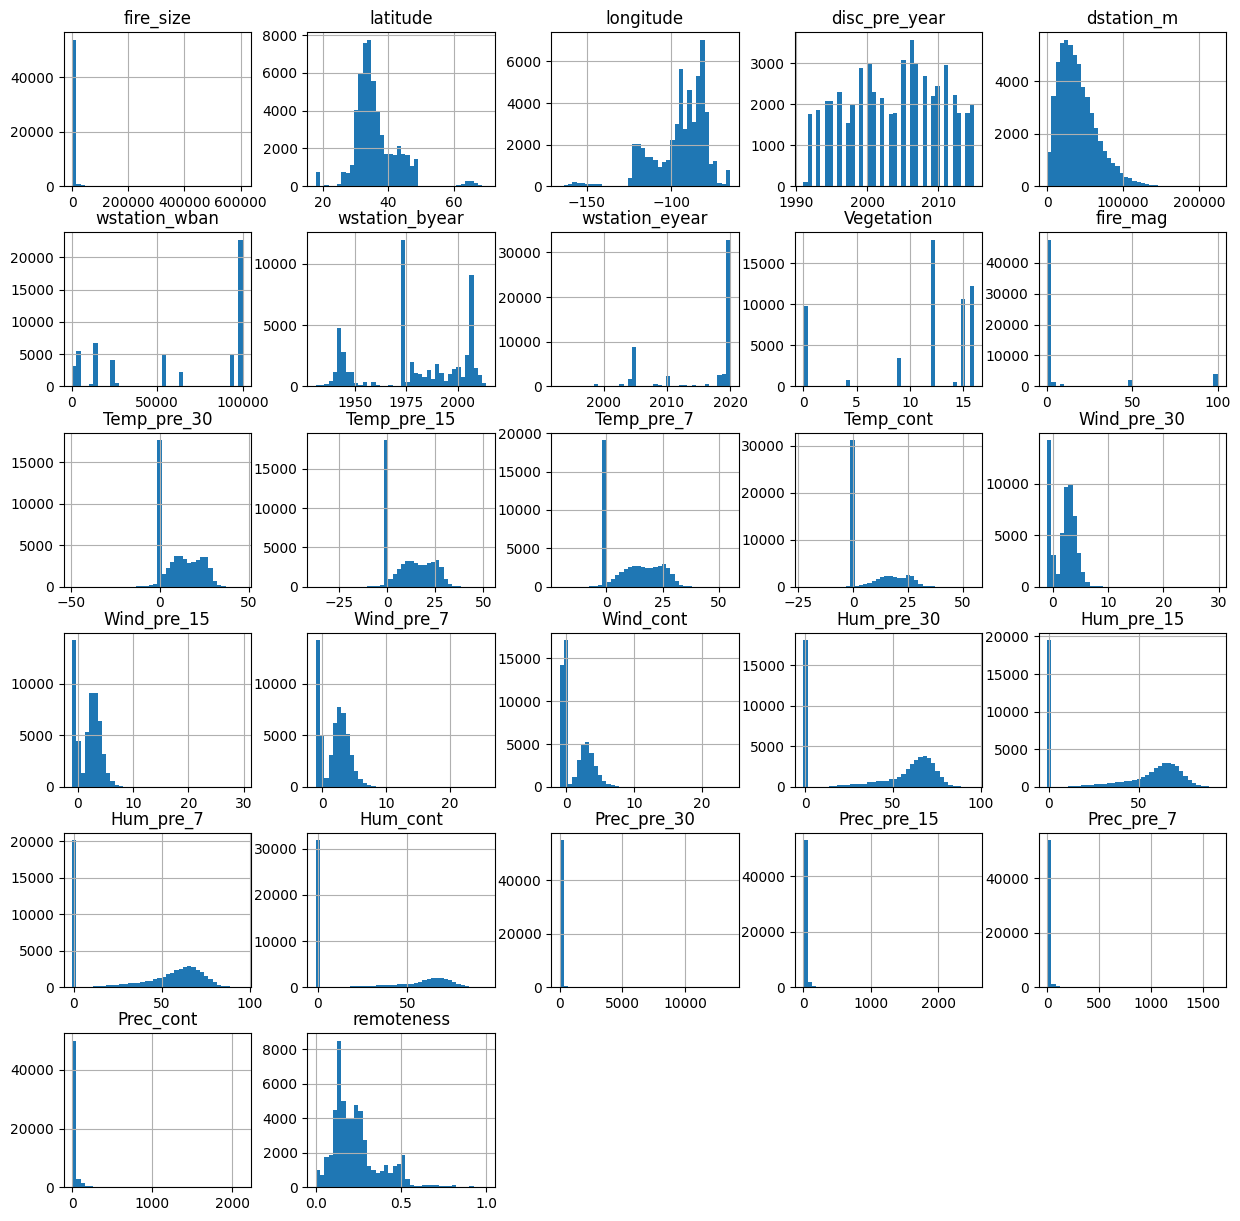

In [ ]:
#To plot a histogram for each numerical attribute
wildfire.hist(bins=40, figsize=(15,15))
plt.suptitle("Histograms of Numeric Features", fontsize=20)
plt.show()

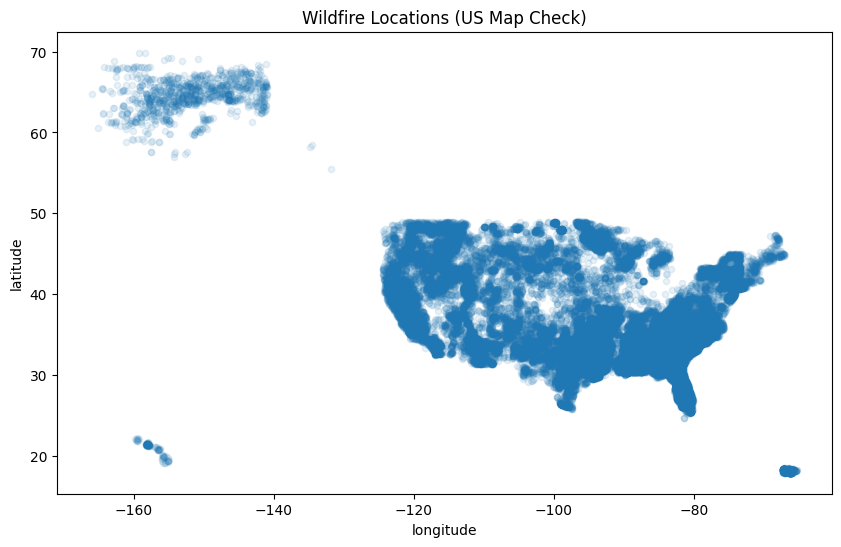

In [ ]:
#Plotting Longitude and latitude to confirm US map
wildfire.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1, figsize=(10,6))
plt.title("Wildfire Locations (US Map Check)")
plt.show()

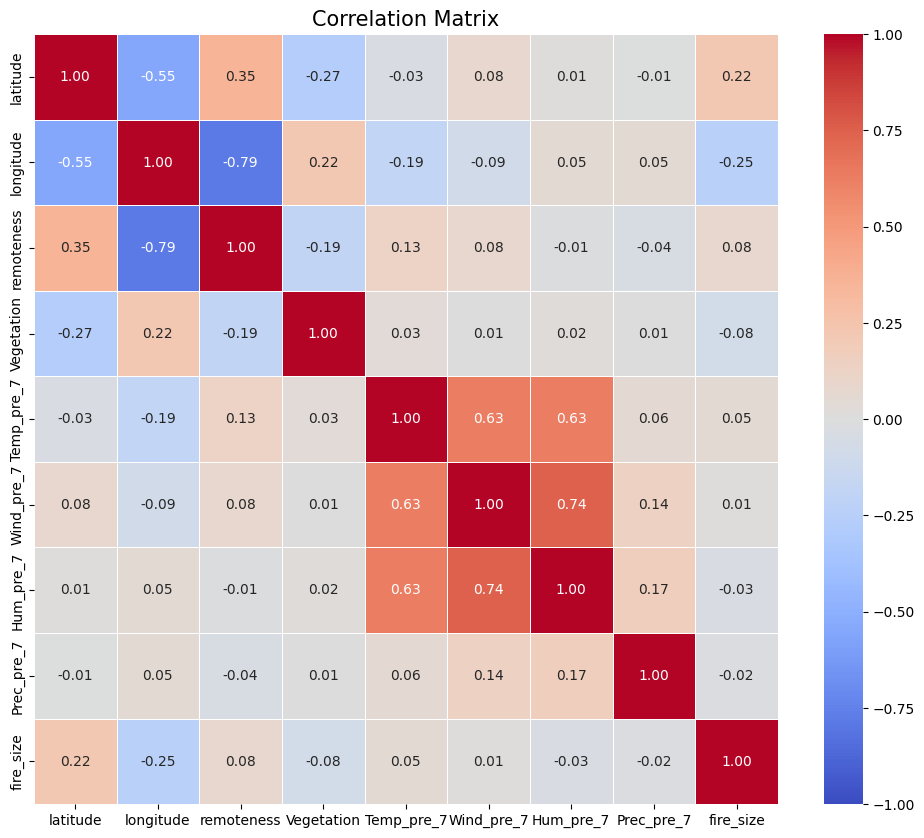

In [ ]:
#Corelation Matrix
cols_to_check = [
    'latitude', 'longitude', 'remoteness', 'Vegetation',
    'Temp_pre_7', 'Wind_pre_7', 'Hum_pre_7', 'Prec_pre_7',
    'fire_size'
]

plt.figure(figsize=(12, 10))
sns.heatmap(wildfire[cols_to_check].corr(),
            annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=15)
plt.show()

#Data Cleaning

In [ ]:
# Load the dataframe
df = wildfire.copy()

#Cleaning unnecessary features
wildfire = wildfire.drop(['Unnamed: 0.1', 'Unnamed: 0','fire_name'], axis=1)
display(wildfire.head())

features_to_impute = [
    'Temp_cont','Wind_cont','Hum_cont',
    'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7',
    'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7',
    'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7',
    'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7'
]

# Replace -1.0 with NaN
print("Replacing -1.0 with NaN...")
for col in features_to_impute:
    df[col] = df[col].replace(-1.000000, np.nan)

# Impute NaN values with the Median
print("Imputing missing values with Median...")
imputer = SimpleImputer(strategy="median")
df[features_to_impute] = imputer.fit_transform(df[features_to_impute])

print("Imputation complete.")

,fire_size,fire_size_class,stat_cause_descr,latitude,longitude,state,disc_clean_date,cont_clean_date,discovery_month,disc_date_final,...,Wind_cont,Hum_pre_30,Hum_pre_15,Hum_pre_7,Hum_cont,Prec_pre_30,Prec_pre_15,Prec_pre_7,Prec_cont,remoteness
0,10.0,C,Missing/Undefined,18.105072,-66.753044,PR,2/11/2007,NaN,Feb,NaN,...,3.250413,78.216590,76.793750,76.381579,78.724370,0.0,0.0,0.0,0.0,0.017923
1,3.0,B,Arson,35.038330,-87.610000,TN,12/11/2006,NaN,Dec,NaN,...,2.122320,70.840000,65.858911,55.505882,81.682678,59.8,8.4,0.0,86.8,0.184355
2,60.0,C,Arson,34.947800,-88.722500,MS,2/29/2004,NaN,Feb,NaN,...,3.369050,75.531629,75.868613,76.812834,65.063800,168.8,42.2,18.1,124.5,0.194544
3,1.0,B,Debris Burning,39.641400,-119.308300,NV,6/6/2005,6/6/2005,Jun,6/6/2005 2:14,...,0.000000,44.778429,37.140811,35.353846,0.000000,10.4,7.2,0.0,0.0,0.487447
4,2.0,B,Miscellaneous,30.700600,-90.591400,LA,9/22/1999,NaN,Sep,NaN,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,0.214633


Replacing -1.0 with NaN...
Imputing missing values with Median...
Imputation complete.


#Feature Engineering

In [ ]:
# Define Feature Lists
target_column = 'fire_size'

numeric_features = [
    'latitude', 'longitude', 'disc_pre_year', 'dstation_m', 'Vegetation', 'remoteness',
    'Temp_pre_30', 'Temp_pre_15', 'Temp_pre_7',
    'Wind_pre_30', 'Wind_pre_15', 'Wind_pre_7',
    'Hum_pre_30', 'Hum_pre_15', 'Hum_pre_7',
    'Prec_pre_30', 'Prec_pre_15', 'Prec_pre_7'
]

categorical_features = [
    'stat_cause_descr',
    'state',
    'discovery_month'
]

# Process Numeric Features
X_numeric = df[numeric_features].copy()

# Process Categorical Features (One-Hot Encoding)
X_categorical = df[categorical_features].copy()
X_categorical_encoded = pd.get_dummies(X_categorical, drop_first=True)

# Combine into X_full
X_full = pd.concat([X_numeric, X_categorical_encoded], axis=1)

# Transform Target (Log Transform)
y_full = np.log1p(df[target_column])

# Synchronize X and y
y_full = y_full.dropna()
X_full = X_full.loc[y_full.index]

print(f"Feature Engineering Complete.")
print(f"Final X shape: {X_full.shape}")
print(f"Final y shape: {y_full.shape}")

Feature Engineering Complete.
Final X shape: (55367, 91)
Final y shape: (55367,)


#Train/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(44293, 91)

In [ ]:
X_test.shape

(11074, 91)

In [ ]:
y_test.shape

(11074,)

In [ ]:
y_train.shape

(44293,)

#Feature Scaling

In [ ]:
# Create Scaler
scaler = StandardScaler()

# Create copies to avoid messing up the originals
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on TRAIN numeric columns only
scaler.fit(X_train[numeric_features])

# Transform TRAIN and TEST numeric columns
X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling finished for Linear Regression and SVM.")

Scaling finished for Linear Regression and SVM.


#Linear Regression

Training Linear Regression Model...
Training RMSE (log-scale): 1.9662
Training MAE (log-scale): 1.3636
Training RMSE (actual scale): 14545.64
Training MAE (actual scale): 1916.77


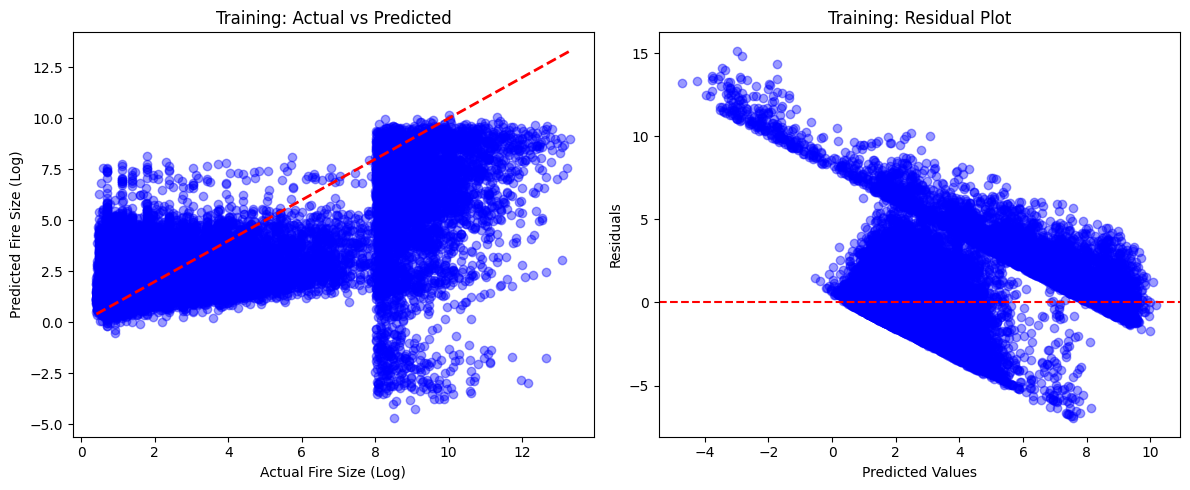


Test RMSE (log-scale): 1.9917
Test MAE (log-scale): 1.3688
Test R-squared: 0.4139


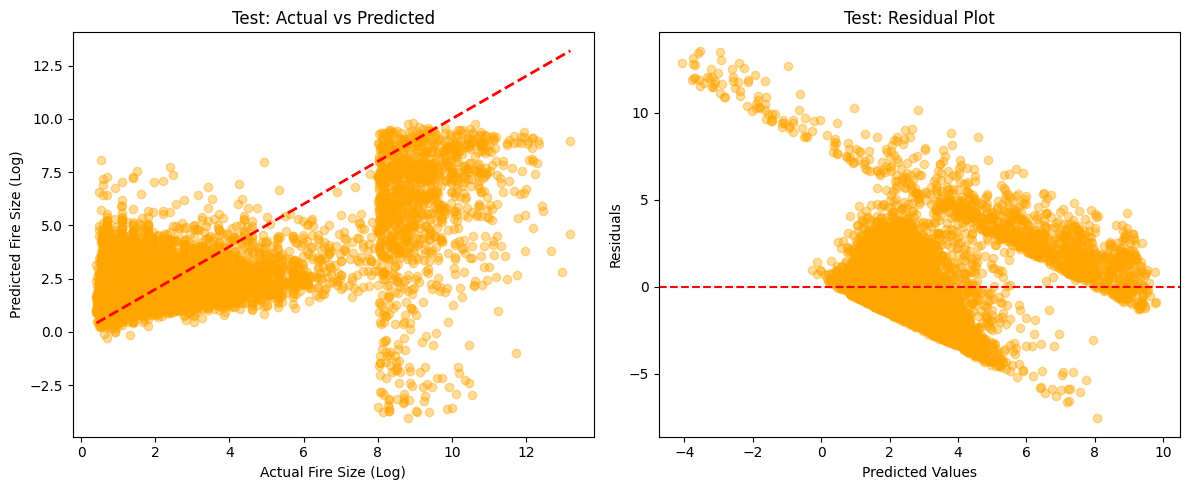

In [17]:
print("Training Linear Regression Model...")
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Predict on training set
y_train_pred = lin_reg.predict(X_train_scaled)

# Convert back to actual scale (hectares) for interpretation
y_train_pred_actual = np.expm1(y_train_pred)
y_train_actual = np.expm1(y_train)

# Log Scale Metrics (Training)
rmse_train_log = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train_log = mean_absolute_error(y_train, y_train_pred)
print(f"Training RMSE (log-scale): {rmse_train_log:.4f}")
print(f"Training MAE (log-scale): {mae_train_log:.4f}")

# Actual Scale Metrics (Training)
rmse_train_actual = np.sqrt(mean_squared_error(y_train_actual, y_train_pred_actual))
mae_train_actual = mean_absolute_error(y_train_actual, y_train_pred_actual)
print(f"Training RMSE (actual scale): {rmse_train_actual:.2f}")
print(f"Training MAE (actual scale): {mae_train_actual:.2f}")

# Ploting Training Results
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted (Training)
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.4, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel("Actual Fire Size (Log)")
plt.ylabel("Predicted Fire Size (Log)")
plt.title("Training: Actual vs Predicted")

# Plot 2: Residuals (Training)
residuals_train = y_train - y_train_pred
plt.subplot(1, 2, 2)
plt.scatter(y_train_pred, residuals_train, alpha=0.4, color='blue')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Training: Residual Plot")

plt.tight_layout()
plt.show()

# Predict on test set
y_test_pred_lin = lin_reg.predict(X_test_scaled)

# Log Scale Metrics (Test)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_test_pred_lin))
mae_test = mean_absolute_error(y_test, y_test_pred_lin)
r2_lin = r2_score(y_test, y_test_pred_lin)

print(f"\nTest RMSE (log-scale): {rmse_lin:.4f}")
print(f"Test MAE (log-scale): {mae_test:.4f}")
print(f"Test R-squared: {r2_lin:.4f}")

# Ploting Test Results
plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted (Test)
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_lin, alpha=0.4, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Fire Size (Log)")
plt.ylabel("Predicted Fire Size (Log)")
plt.title("Test: Actual vs Predicted")

# Plot 2: Residuals (Test)
residuals_test = y_test - y_test_pred_lin
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred_lin, residuals_test, alpha=0.4, color='orange')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Test: Residual Plot")

plt.tight_layout()
plt.show()

#Decision Tree Regression

Tuning Decision Tree...

Best Tree Params: {'max_depth': 10, 'min_samples_leaf': 10}
Decision Tree Test RMSE: 1.3778
Decision Tree Test R2: 0.7195


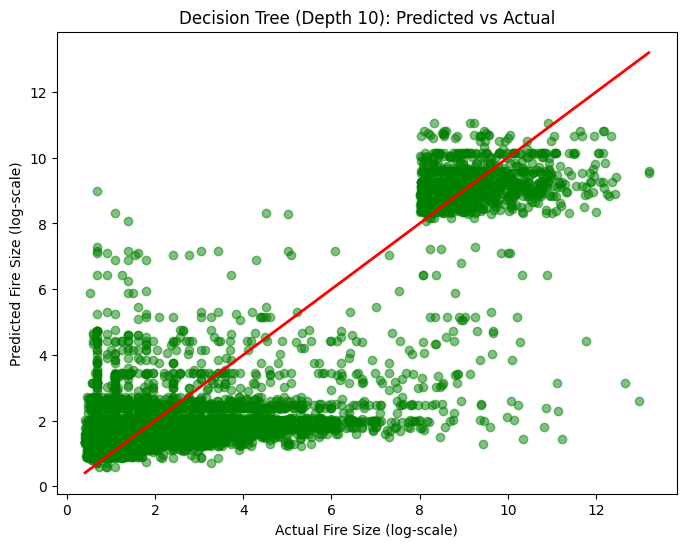

In [18]:
# Grid Search
param_grid = {
    'max_depth': [5, 10, 15, 20, 25, 30],
    'min_samples_leaf': [1, 5, 10, 20]
}

tree_reg = DecisionTreeRegressor(random_state=42)
grid_search_tree = GridSearchCV(tree_reg, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
print("Tuning Decision Tree...")
grid_search_tree.fit(X_train, y_train)

# Evaluate Best Model
best_tree = grid_search_tree.best_estimator_
y_pred_tree = best_tree.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print(f"\nBest Tree Params: {grid_search_tree.best_params_}")
print(f"Decision Tree Test RMSE: {rmse_tree:.4f}")
print(f"Decision Tree Test R2: {r2_tree:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_tree, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)
plt.xlabel("Actual Fire Size (log-scale)")
plt.ylabel("Predicted Fire Size (log-scale)")
plt.title(f"Decision Tree (Depth {grid_search_tree.best_params_['max_depth']}): Predicted vs Actual")
plt.show()

#Random Forest

Tuning Random Forest... 

Best Parameters Found: {'max_depth': 24, 'max_features': 13, 'min_samples_leaf': 2, 'n_estimators': 188}
Final Test RMSE: 1.3820
Final Test R2 Score: 0.7178

--- Top Features ---
                       Feature  Importance
5                   remoteness    0.316704
1                    longitude    0.146906
0                     latitude    0.082316
23  stat_cause_descr_Lightning    0.081512
12                  Hum_pre_30    0.034661
3                   dstation_m    0.032727
13                  Hum_pre_15    0.025827
14                   Hum_pre_7    0.025476
6                  Temp_pre_30    0.018856
8                   Temp_pre_7    0.018574


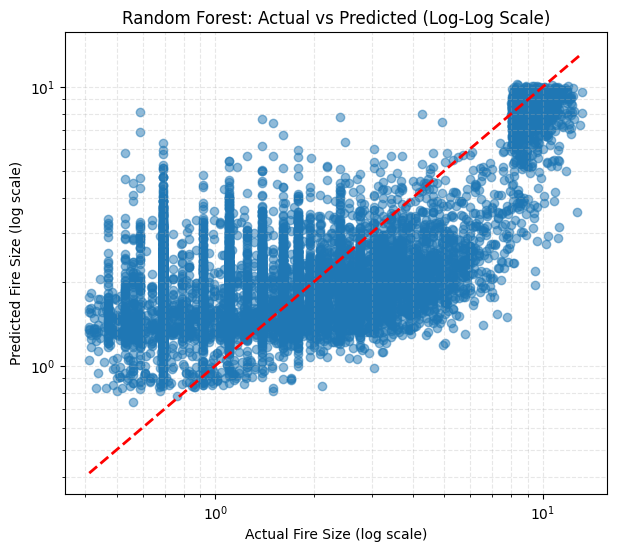

Calculating learning curve...


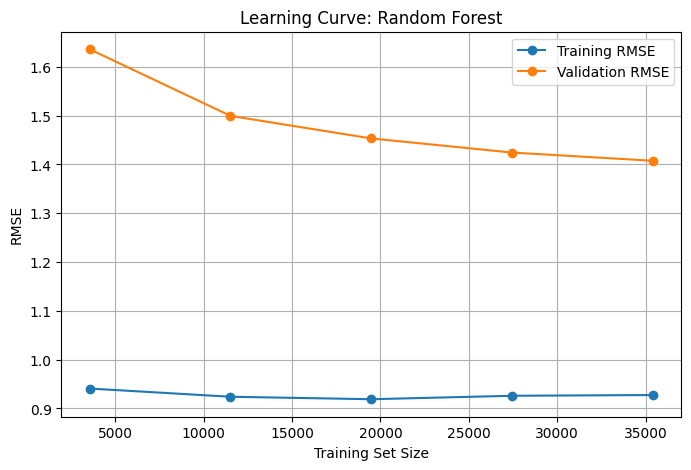

In [19]:
# Hyperparameter Tuning
param_distribs = {
    'n_estimators': randint(low=100, high=300),
    'max_features': randint(low=1, high=20),
    'min_samples_leaf': randint(low=2, high=20),
    'max_depth': randint(low=10, high=50)
}

forest_reg = RandomForestRegressor(random_state=42)

rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=20, cv=5, scoring='neg_mean_squared_error',
                                random_state=42, n_jobs=-1)

print("Tuning Random Forest... ")
rnd_search.fit(X_train, y_train)

# Evaluation
final_model = rnd_search.best_estimator_
print(f"\nBest Parameters Found: {rnd_search.best_params_}")

y_test_pred = final_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
final_r2 = r2_score(y_test, y_test_pred)

print(f"Final Test RMSE: {final_rmse:.4f}")
print(f"Final Test R2 Score: {final_r2:.4f}")

# Feature Importance
importances = final_model.feature_importances_
feature_names = X_train.columns
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Top Features ---")
print(feature_importances_df.head(10))

# Plot 1: Actual vs Predicted (Log-Log Scale)
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Actual Fire Size (log scale)")
plt.ylabel("Predicted Fire Size (log scale)")
plt.title("Random Forest: Actual vs Predicted (Log-Log Scale)")
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

# Plot 2: Learning Curve
print("Calculating learning curve...")
train_sizes, train_scores, test_scores = learning_curve(
    final_model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_rmse_lc = np.sqrt(-train_scores.mean(axis=1))
test_rmse_lc = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_rmse_lc, 'o-', label="Training RMSE")
plt.plot(train_sizes, test_rmse_lc, 'o-', label="Validation RMSE")
plt.xlabel("Training Set Size")
plt.ylabel("RMSE")
plt.legend()
plt.title("Learning Curve: Random Forest")
plt.grid(True)
plt.show()

# Support Vector Regression (SVR)

Training SVR model with RBF kernel and cross-validation...

--- SVR (RBF) Cross-Validation Scores (RMSE) ---
Mean RMSE: 1.6508
Std RMSE: 0.0255

--- SVR (RBF) Test Evaluation ---
Test RMSE (log-scale): 1.6153
Test R-squared: 0.6145


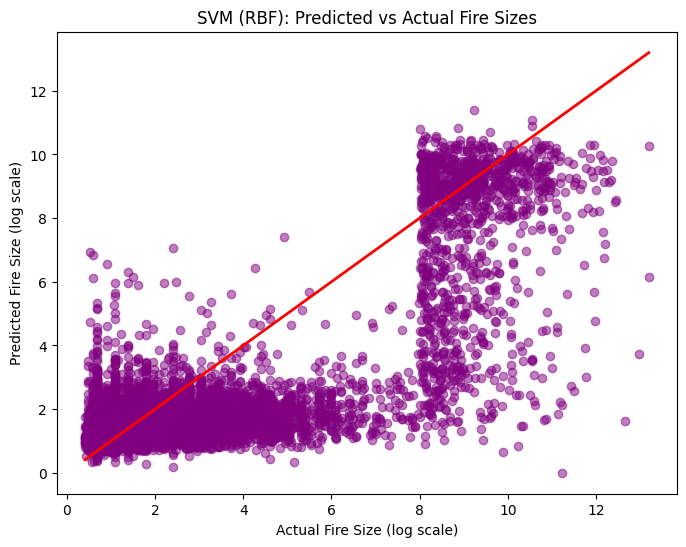

In [ ]:
# Train SVM with RBF kernel and cross-validation
print("Training SVR model with RBF kernel and cross-validation...")
svm_reg_rbf = SVR(kernel="rbf")

# Perform cross-validation
scores = cross_val_score(svm_reg_rbf, X_train_scaled, y_train, scoring="neg_mean_squared_error", cv=3, n_jobs=-1)
svm_rmse_scores = np.sqrt(-scores)

print(f"\n--- SVR (RBF) Cross-Validation Scores (RMSE) ---")
print(f"Mean RMSE: {svm_rmse_scores.mean():.4f}")
print(f"Std RMSE: {svm_rmse_scores.std():.4f}")

# Fit the model on the full training data to make predictions on the test set
svm_reg_rbf.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred_svm_rbf = svm_reg_rbf.predict(X_test_scaled)
svm_rmse_rbf = np.sqrt(mean_squared_error(y_test, y_pred_svm_rbf))
svm_r2_rbf = r2_score(y_test, y_pred_svm_rbf);

print(f"\n--- SVR (RBF) Test Evaluation ---")
print(f"Test RMSE (log-scale): {svm_rmse_rbf:.4f}")
print(f"Test R-squared: {svm_r2_rbf:.4f}")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_svm_rbf, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel("Actual Fire Size (log scale)")
plt.ylabel("Predicted Fire Size (log scale)")
plt.title("SVM (RBF): Predicted vs Actual Fire Sizes")
plt.show()

#Result Visualization

/tmp/ipython-input-3358184051.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2 Score', y='Model', data=comparison_df, palette='viridis')


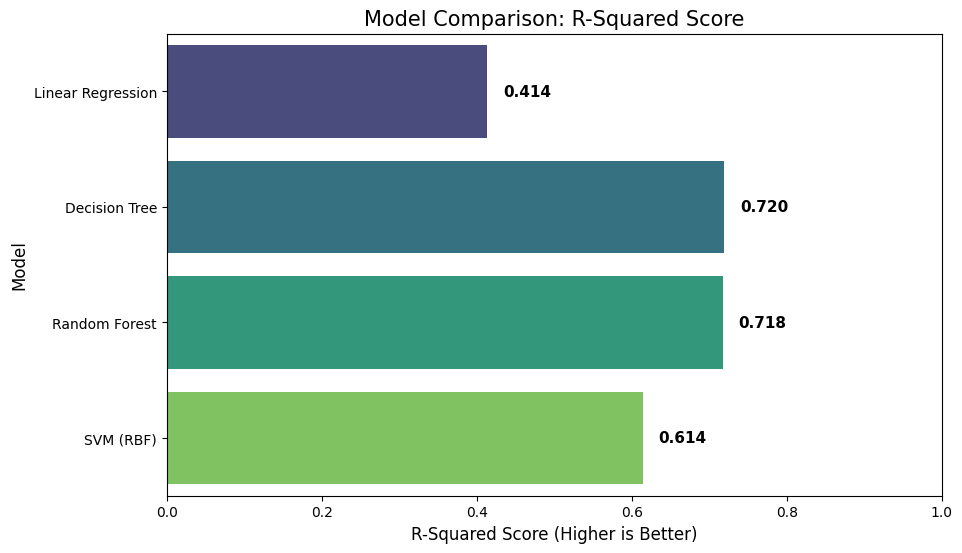

/tmp/ipython-input-3358184051.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


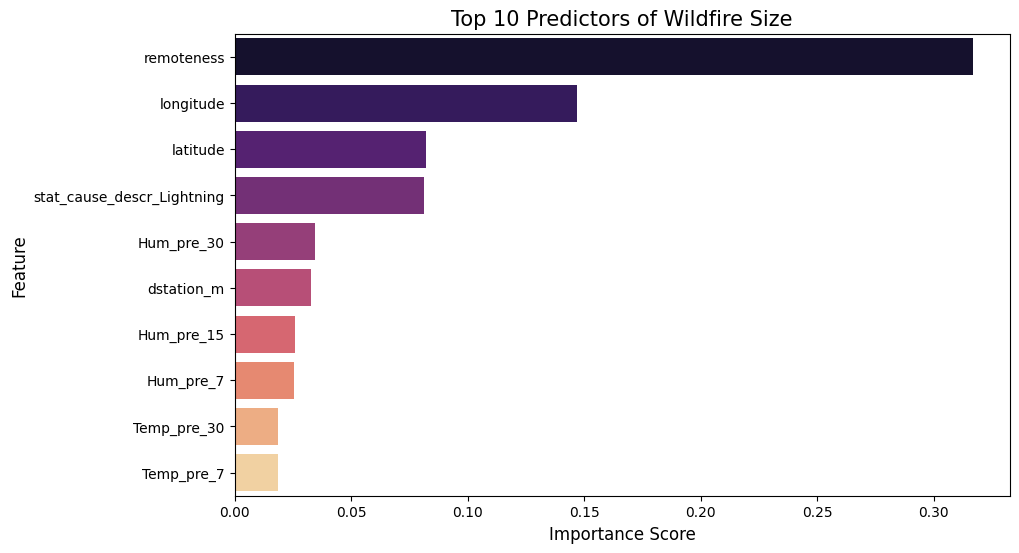

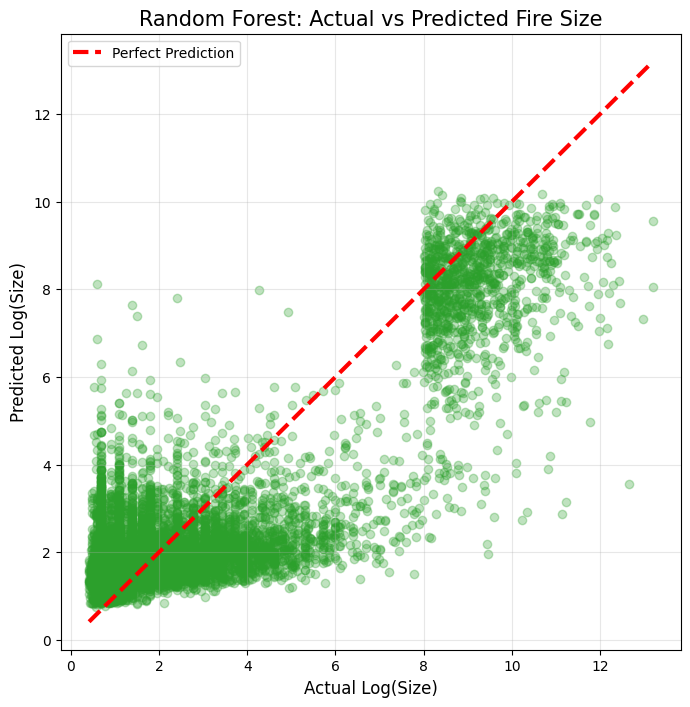

In [20]:
# ==========================================
# GRAPH 1: MODEL COMPARISON (The Scoreboard)
# ==========================================
# We assume you have run Blocks 6, 7, 8, and 9 and have these variables.

models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'SVM (RBF)']
r2_scores = [r2_lin, r2_tree, final_r2, svm_r2_rbf] # Use svm_r2_rbf for the updated SVM score

# Create a DataFrame for plotting
comparison_df = pd.DataFrame({'Model': models, 'R2 Score': r2_scores})

plt.figure(figsize=(10, 6))
sns.barplot(x='R2 Score', y='Model', data=comparison_df, palette='viridis')
plt.title('Model Comparison: R-Squared Score', fontsize=15)
plt.xlabel('R-Squared Score (Higher is Better)', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.0) # R2 ranges from 0 to 1

# Add the text numbers on the bars
for index, value in enumerate(r2_scores):
    plt.text(value + 0.02, index, f'{value:.3f}', va='center', fontsize=11, fontweight='bold')

plt.show()


# ==========================================
# GRAPH 2: FEATURE IMPORTANCE (The Insight)
# ==========================================
# Using the 'final_model' from the Random Forest block

importances = final_model.feature_importances_
feature_names = X_train.columns

# Create a nice DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10) # Top 10 only

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Top 10 Predictors of Wildfire Size', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()


# ==========================================
# GRAPH 3: ACTUAL VS PREDICTED (The Accuracy)
# ==========================================
# Using the best model (Random Forest) predictions

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='#2ca02c') # Green dots

# The "Perfect Prediction" Line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction')

plt.title('Random Forest: Actual vs Predicted Fire Size', fontsize=15)
plt.xlabel('Actual Log(Size)', fontsize=12)
plt.ylabel('Predicted Log(Size)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()